# NFXP + EM-algoritme med to latente forbrugertyper

Udvidelse af `nfxp_agu2022.py` til et **finit-blandingsmodel** med K = 2 latente forbrugertyper.  
Estimationsmetode: **EM-algoritme** (Dempster, Laird & Rubin 1977) med NFXP som indre løser i M-trinnet.

## Model
Hver forbruger $i$ trækker én gang en permanent latent type $k_i \in \{1, 2\}$:
$$k_i = 1 \text{ med sandsynlighed } \pi, \quad k_i = 2 \text{ med sandsynlighed } 1-\pi$$

Den observerede sandsynlighed:
$$L_i(\theta) = \pi \cdot L_i(\theta_1) + (1-\pi) \cdot L_i(\theta_2), \qquad L_i(\theta_k) = \prod_{t=1}^{T} P(y_{it} \mid \ell_{it}, d_{it}, e_{it}; \theta_k)$$

## EM-algoritme
**E-trin:** posterior type-sandsynligheder
$$w_{i1}^{(m)} = \frac{\pi^{(m)} L_i(\theta_1^{(m)})}{\pi^{(m)} L_i(\theta_1^{(m)}) + (1-\pi^{(m)}) L_i(\theta_2^{(m)})}$$

**M-trin:** for $k = 1, 2$ løses hvert delproblem med **NFXP** (varm start):
$$\theta_k^{(m+1)} = \arg\max_{\theta} \sum_i w_{ik}^{(m)} \log L_i(\theta), \qquad \pi^{(m+1)} = \frac{1}{N}\sum_i w_{i1}^{(m)}$$

**Konvergenskriterium:** $\sup$-norm på ændring i $(\pi, \theta_1, \theta_2) < \texttt{tol}$

## Sande DGP-parametre
| | Type 1 — mærkeloyale | Type 2 — tilbudsjaegere |
|---|---|---|
| $\alpha_2$ | 0.30 | 0.10 |
| $\gamma$ | 0.50 | 0.80 |
| $\beta_{sc,12}$ | 0.55 | 0.20 |
| $\beta_{sc,21}$ | 0.50 | 0.15 |
| $\beta_{dep,1}$ | 0.25 | 0.40 |
| $\beta_{dep,2}$ | 0.25 | 0.40 |
| $\pi$ | **0.40** | — |

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Base-model: importér alle primitiver og hjælpefunktioner fra det eksisterende NFXP-modul
from nfxp_agu2022 import (
    J, T, N, D_MAX, DELTA, MU,
    PARAM_NAMES, THETA_TRUE,
    unpack, solve_vfi, compute_ccps,
    simulate_panel, _sample_rows,
    PROMO_TRANS, N_PROMO,
    MC_SEED,
)

print(f'Base-model importeret: J={J}, T={T}, N={N}, D_MAX={D_MAX}')
print(f'Homogene sande parametre: {dict(zip(PARAM_NAMES, np.round(THETA_TRUE, 3)))}')

Base-model importeret: J=2, T=52, N=2000, D_MAX=2
Homogene sande parametre: {'alpha_2': 0.3, 'gamma': 0.5, 'beta_sc_12': 0.55, 'beta_sc_21': 0.5, 'beta_dep_1': 0.25, 'beta_dep_2': 0.25}


## 1. Sande DGP-parametre for to typer

In [2]:
# Type 1: mærkeloyale / lav prisfølsomhed (samme som det homogene DGP)
THETA_1_TRUE = THETA_TRUE.copy()

# Type 2: tilbudsjaegere / høj prisfølsomhed, lave skifteomkostninger
THETA_2_TRUE = np.array([
    0.10,   # alpha_2:     svagere præference for mærke 2
    0.80,   # gamma:       60 % mere prisfølsom end type 1
    0.20,   # beta_sc_12:  lav skifteomkostning mærke 1→2
    0.15,   # beta_sc_21:  lav skifteomkostning mærke 2→1
    0.40,   # beta_dep_1:  hurtigere forringelse af lagerbeholdning
    0.40,   # beta_dep_2
])

PI_TRUE = 0.40            # P(forbruger er type 1)

EM_MAXITER = 40           # maks. EM-iterationer
EM_TOL     = 1e-4         # konvergenstolerance (sup-norm)

# Monte Carlo-indstillinger for EM-modellen
EM_MC_REPS = 10           # replikationer (færre end homogent MC pga. beregningsbyrde)
EM_MC_N    = 1_000        # forbrugere pr. panel

# Parameternavne: pi + 6 type-1 + 6 type-2
PARAM_NAMES_EM = (['pi']
                  + [f'{n}_k1' for n in PARAM_NAMES]
                  + [f'{n}_k2' for n in PARAM_NAMES])
THETA_EM_TRUE = np.concatenate([[PI_TRUE], THETA_1_TRUE, THETA_2_TRUE])

print('Type 1:', dict(zip(PARAM_NAMES, THETA_1_TRUE)))
print('Type 2:', dict(zip(PARAM_NAMES, THETA_2_TRUE)))
print(f'pi_true = {PI_TRUE}')

Type 1: {'alpha_2': 0.3, 'gamma': 0.5, 'beta_sc_12': 0.55, 'beta_sc_21': 0.5, 'beta_dep_1': 0.25, 'beta_dep_2': 0.25}
Type 2: {'alpha_2': 0.1, 'gamma': 0.8, 'beta_sc_12': 0.2, 'beta_sc_21': 0.15, 'beta_dep_1': 0.4, 'beta_dep_2': 0.4}
pi_true = 0.4


## 2. Log-sandsynlighed pr. forbruger

In [3]:
def log_likelihood_per_consumer(data: dict, P: np.ndarray) -> np.ndarray:
    """
    Beregner log-sandsynlighed summeret over T perioder for HVER forbruger.

    Returner (N,) array: sum_t log P(y_it | state_it; theta).
    Nødvendig til EM's E-trin, hvor vi har brug for individuelle bidrag.
    """
    Y, L, D, E = data['Y'], data['L'], data['D'], data['E_IDX']
    probs = P[L - 1, D, E, Y]                               # (N, T)
    return np.sum(np.log(np.maximum(probs, 1e-300)), axis=1) # (N,)

## 3. Vægtet NFXP — M-trinets indre løser

In [4]:
def nfxp_objective_weighted(theta: np.ndarray,
                             data: dict,
                             weights: np.ndarray) -> float:
    """
    Vægtet negativ log-sandsynlighed brugt i EM's M-trin.

    Indre loop (VFI) løses for det aktuelle theta, og den resulterende
    log-sandsynlighed vægtes med forbrugerens posterior type-sandsynlighed.
    """
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V  = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P  = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    ll = log_likelihood_per_consumer(data, P)  # (N,)
    return -float(np.dot(weights, ll))


def estimate_nfxp_weighted(data: dict,
                            weights: np.ndarray,
                            theta0: np.ndarray = None) -> object:
    """
    NFXP med forbrugervægte. Bruges som M-trins solver for én type ad gangen.

    Varm start: theta0 sættes til forrige iterations estimat for hurtigere
    konvergens igennem EM-løkken.
    """
    if theta0 is None:
        theta0 = np.array([0.1, 0.3, 0.3, 0.3, 0.1, 0.1])
    return minimize(
        fun=nfxp_objective_weighted,
        x0=theta0,
        args=(data, weights),
        method='Nelder-Mead',
        options={'maxiter': 10_000, 'xatol': 1e-5,
                 'fatol': 1e-5, 'adaptive': True},
    )

## 4. E-trin

In [5]:
def em_e_step(ll1: np.ndarray, ll2: np.ndarray, pi: float) -> np.ndarray:
    """
    E-trin: posterior sandsynlighed for type 1 given forbruger i's data.

    Beregnes i log-rum (logaddexp) for numerisk stabilitet — L_i er et
    produkt af T sandsynligheder og kan være ekstremt lille i float64.

    Returnerer (N,) array: w_i1 = P(type=1 | data_i, theta^(m)).
    """
    log_pi1 = np.log(np.clip(pi,       1e-300, 1 - 1e-300))
    log_pi2 = np.log(np.clip(1.0 - pi, 1e-300, 1 - 1e-300))
    log_num1  = log_pi1 + ll1
    log_num2  = log_pi2 + ll2
    log_denom = np.logaddexp(log_num1, log_num2)  # log-sum-exp trick
    return np.exp(log_num1 - log_denom)

## 5. Simulation fra to-type DGP

In [6]:
def simulate_panel_2types(P1_true: np.ndarray,
                          P2_true: np.ndarray,
                          pi_true: float = PI_TRUE,
                          n_consumers: int = N,
                          n_periods: int = T,
                          seed=None) -> dict:
    """
    Simulerer et forbrugerpanel fra det to-type DGP.

    Hver forbruger i tildeleles én permanent latent type k_i ~ Bernoulli(pi_true).
    Type-k forbrugere bruger CCPs P_k i alle T perioder.

    Returnerer samme dict som simulate_panel plus TYPE: (N,) sande typer.
    """
    rng = np.random.default_rng(seed)

    type1_mask = rng.random(n_consumers) < pi_true   # True = type 1
    types = np.where(type1_mask, 1, 2).astype(int)

    Y     = np.zeros((n_consumers, n_periods), dtype=int)
    L     = np.zeros((n_consumers, n_periods), dtype=int)
    D     = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    ell   = rng.integers(1, J + 1,    size=n_consumers)
    dur   = rng.integers(0, D_MAX + 1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO,  size=n_consumers)

    for t in range(n_periods):
        L[:, t]     = ell
        D[:, t]     = dur
        E_IDX[:, t] = e_idx

        probs1 = P1_true[ell - 1, np.minimum(dur, D_MAX), e_idx, :]  # (N, J+1)
        probs2 = P2_true[ell - 1, np.minimum(dur, D_MAX), e_idx, :]  # (N, J+1)
        probs  = np.where(type1_mask[:, None], probs1, probs2)

        y = _sample_rows(rng, probs)
        Y[:, t] = y

        bought = y > 0
        ell    = np.where(bought, y, ell)
        dur    = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        e_idx  = _sample_rows(rng, PROMO_TRANS[e_idx])

    return {'Y': Y, 'L': L, 'D': D, 'E_IDX': E_IDX, 'TYPE': types}

## 6. EM-algoritmen

In [7]:
def estimate_em(data: dict,
                pi0: float,
                theta1_0: np.ndarray,
                theta2_0: np.ndarray,
                n_iter: int = EM_MAXITER,
                tol_em: float = EM_TOL,
                verbose: bool = True) -> dict:
    """
    EM-algoritme for to-type blandingsmodellen.

    E-trin:  beregn posterior w_i1 = P(type=1 | data_i) i log-rum.
    M-trin:  løs to vægtede NFXP-problemer (ét pr. type) med varm start.

    Returnerer dict: pi, theta1, theta2, history, n_iter, converged.
    """
    pi     = float(pi0)
    theta1 = theta1_0.copy()
    theta2 = theta2_0.copy()
    history = []

    if verbose:
        n_obs, t_obs = data['Y'].shape
        print(f'EM  (K=2)  |  N={n_obs}, T={t_obs}')
        print(f'  Start  pi={pi:.3f}')
        print(f'         theta1={np.round(theta1, 3)}')
        print(f'         theta2={np.round(theta2, 3)}')
        print(f"\n  {'Iter':>4}  {'pi':>7}  {'delta':>10}")
        print('  ' + '-' * 26)

    for it in range(1, n_iter + 1):

        # ── E-trin ────────────────────────────────────────────────────────
        a1, g1, sc1, dep1 = unpack(theta1)
        a2, g2, sc2, dep2 = unpack(theta2)

        V1 = solve_vfi(a1, g1, sc1, dep1)
        V2 = solve_vfi(a2, g2, sc2, dep2)
        P1 = compute_ccps(V1, a1, g1, sc1, dep1)
        P2 = compute_ccps(V2, a2, g2, sc2, dep2)

        ll1 = log_likelihood_per_consumer(data, P1)   # (N,)
        ll2 = log_likelihood_per_consumer(data, P2)   # (N,)
        w1  = em_e_step(ll1, ll2, pi)                 # (N,) posterior
        w2  = 1.0 - w1

        # ── M-trin: opdater pi ────────────────────────────────────────────
        pi_new = float(w1.mean())

        # ── M-trin: opdater type-parametre via NFXP (spring over hvis degenereret)
        theta1_new = (estimate_nfxp_weighted(data, w1, theta0=theta1).x
                      if w1.sum() > 1e-6 else theta1)
        theta2_new = (estimate_nfxp_weighted(data, w2, theta0=theta2).x
                      if w2.sum() > 1e-6 else theta2)

        # ── Konvergensmål ─────────────────────────────────────────────────
        delta = max(
            abs(pi_new - pi),
            float(np.max(np.abs(theta1_new - theta1))),
            float(np.max(np.abs(theta2_new - theta2))),
        )

        pi, theta1, theta2 = pi_new, theta1_new, theta2_new
        history.append({'pi': pi, 'theta1': theta1.copy(), 'theta2': theta2.copy()})

        if verbose:
            print(f'  {it:>4}  {pi:>7.4f}  {delta:>10.6f}')

        if delta < tol_em:
            if verbose:
                print(f'\n  => Konvergerede efter {it} iterationer.')
            return {'pi': pi, 'theta1': theta1, 'theta2': theta2,
                    'history': history, 'n_iter': it, 'converged': True}

    if verbose:
        print(f'\n  => Konvergerede IKKE efter {n_iter} iterationer.')
    return {'pi': pi, 'theta1': theta1, 'theta2': theta2,
            'history': history, 'n_iter': n_iter, 'converged': False}

## 7. Label-switching korrektion

In [8]:
def canonicalize(pi, theta1, theta2):
    """
    Kanonisk label-rækkefølge: type 1 er altid typen med LAVEST gamma (theta[1]).

    I Monte Carlo kan EM finde typerne i omvendt rækkefølge (label-switching).
    Denne funktion bytter labels om nødvendigt, så aggregeringen er meningsfuld.
    """
    if float(theta1[1]) > float(theta2[1]):
        return 1.0 - pi, theta2.copy(), theta1.copy()
    return float(pi), theta1.copy(), theta2.copy()

## 8. Pilot-kørsel (ét datasæt)

In [9]:
# Løs DP ved sande parametre for begge typer (gøres kun én gang)
a1, g1, sc1, d1 = unpack(THETA_1_TRUE)
a2, g2, sc2, d2 = unpack(THETA_2_TRUE)
V1_true = solve_vfi(a1, g1, sc1, d1)
V2_true = solve_vfi(a2, g2, sc2, d2)
P1_true = compute_ccps(V1_true, a1, g1, sc1, d1)
P2_true = compute_ccps(V2_true, a2, g2, sc2, d2)
print('DP løst for begge typer.')

# Simulér ét to-type panel
pilot_data = simulate_panel_2types(P1_true, P2_true, pi_true=PI_TRUE, seed=42)
print(f"Realiseret andel type 1: {(pilot_data['TYPE']==1).mean():.3f}  (sand={PI_TRUE})")
print(f"Samlet købsrate:         {(pilot_data['Y']>0).mean():.1%}")

DP løst for begge typer.
Realiseret andel type 1: 0.395  (sand=0.4)
Samlet købsrate:         49.1%


In [10]:
# Startværdier: type 1 nær lav gamma, type 2 nær høj gamma
theta1_0 = THETA_1_TRUE + np.array([ 0.02,  0.05,  0.03,  0.03,  0.02,  0.02])
theta2_0 = THETA_2_TRUE + np.array([-0.02, -0.05, -0.03, -0.03,  0.02,  0.02])
pi0      = 0.50

t0 = time.perf_counter()
pilot_result = estimate_em(pilot_data, pi0=pi0,
                            theta1_0=theta1_0, theta2_0=theta2_0,
                            verbose=True)
print(f'\nEM-tid: {time.perf_counter()-t0:.1f}s')

EM  (K=2)  |  N=2000, T=52
  Start  pi=0.500
         theta1=[0.32 0.55 0.58 0.53 0.27 0.27]
         theta2=[0.08 0.75 0.17 0.12 0.42 0.42]

  Iter       pi       delta
  --------------------------
     1   0.4772    0.078623
     2   0.4758    0.021550
     3   0.4748    0.007863
     4   0.4737    0.009329
     5   0.4726    0.005676
     6   0.4715    0.005495
     7   0.4705    0.005337
     8   0.4694    0.005226
     9   0.4684    0.005628
    10   0.4673    0.005204
    11   0.4663    0.008406
    12   0.4653    0.004855
    13   0.4643    0.005282
    14   0.4632    0.004936
    15   0.4622    0.006785
    16   0.4612    0.003094
    17   0.4602    0.003506
    18   0.4592    0.003436
    19   0.4583    0.002005
    20   0.4573    0.002769
    21   0.4563    0.005147
    22   0.4553    0.002202
    23   0.4544    0.002654
    24   0.4534    0.002011
    25   0.4525    0.003342
    26   0.4516    0.003962
    27   0.4506    0.004111
    28   0.4497    0.001892
    29   0.4488  

In [11]:
# Anvend label-korrektion og print sammenligningstabel
pi_c, t1_c, t2_c = canonicalize(pilot_result['pi'],
                                  pilot_result['theta1'],
                                  pilot_result['theta2'])

print(f"{'Parameter':<22}  {'Sand':>8}  {'EM-NFXP':>8}  {'Bias':>8}")
print('-' * 52)
print(f"{'pi':<22}  {PI_TRUE:>8.4f}  {pi_c:>8.4f}  {pi_c-PI_TRUE:>+8.4f}")
for k, name in enumerate(PARAM_NAMES):
    print(f"{name+'_k1':<22}  {THETA_1_TRUE[k]:>8.4f}  {t1_c[k]:>8.4f}  {t1_c[k]-THETA_1_TRUE[k]:>+8.4f}")
    print(f"{name+'_k2':<22}  {THETA_2_TRUE[k]:>8.4f}  {t2_c[k]:>8.4f}  {t2_c[k]-THETA_2_TRUE[k]:>+8.4f}")

Parameter                   Sand   EM-NFXP      Bias
----------------------------------------------------
pi                        0.4000    0.4393   +0.0393
alpha_2_k1                0.3000    0.2954   -0.0046
alpha_2_k2                0.1000    0.0532   -0.0468
gamma_k1                  0.5000    0.5238   +0.0238
gamma_k2                  0.8000    0.7778   -0.0222
beta_sc_12_k1             0.5500    0.4910   -0.0590
beta_sc_12_k2             0.2000    0.1666   -0.0334
beta_sc_21_k1             0.5000    0.4549   -0.0451
beta_sc_21_k2             0.1500    0.1494   -0.0006
beta_dep_1_k1             0.2500    0.2489   -0.0011
beta_dep_1_k2             0.4000    0.4047   +0.0047
beta_dep_2_k1             0.2500    0.2696   +0.0196
beta_dep_2_k2             0.4000    0.3983   -0.0017


## 9. Konvergensplot

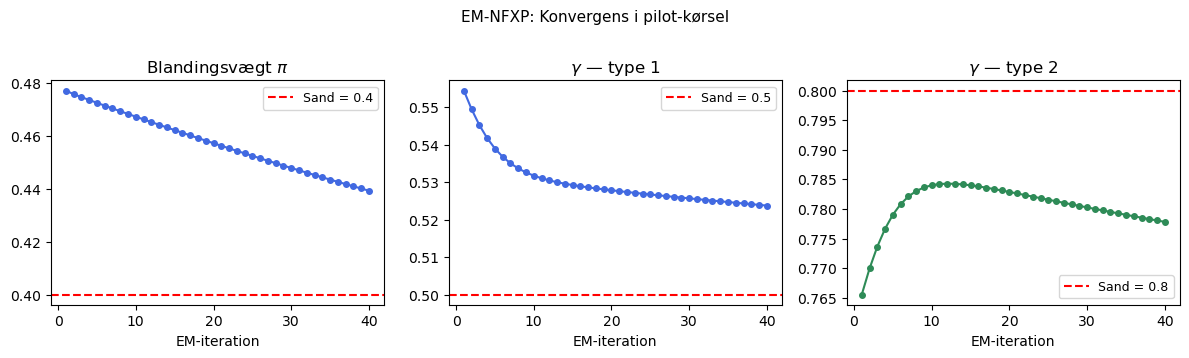

In [12]:
history = pilot_result['history']
iters   = range(1, len(history) + 1)

pi_hist     = [h['pi']        for h in history]
gamma1_hist = [h['theta1'][1] for h in history]
gamma2_hist = [h['theta2'][1] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, vals, true_val, title, col in zip(
    axes,
    [pi_hist, gamma1_hist, gamma2_hist],
    [PI_TRUE, THETA_1_TRUE[1], THETA_2_TRUE[1]],
    [r'Blandingsvægt $\pi$', r'$\gamma$ — type 1', r'$\gamma$ — type 2'],
    ['royalblue', 'royalblue', 'seagreen'],
):
    ax.plot(iters, vals, '-o', color=col, ms=4)
    ax.axhline(true_val, color='red', ls='--', lw=1.5, label=f'Sand = {true_val}')
    ax.set_xlabel('EM-iteration')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('EM-NFXP: Konvergens i pilot-kørsel', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('em_convergence.pdf', bbox_inches='tight')
plt.show()

## 10. Monte Carlo-simulation

In [13]:
def run_monte_carlo_em(n_reps: int = EM_MC_REPS,
                       n_consumers: int = EM_MC_N,
                       seed: int = MC_SEED):
    """
    Monte Carlo-eksperiment for EM-NFXP estimatoren.

    Hvert replikation:
      1. Simulerer nyt to-type panel fra det sande DGP.
      2. Estimerer (pi, theta_1, theta_2) med EM-NFXP.
      3. Anvender kanonisk label-rækkefølge.
      4. Registrerer estimater, bias, og kvadratfejl.

    Returnerer results_df og summary_df.
    """
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Løs DP ved sande parametre én gang — alle rep. bruger samme P_true
    a1, g1, sc1, d1 = unpack(THETA_1_TRUE)
    a2, g2, sc2, d2 = unpack(THETA_2_TRUE)
    V1_t = solve_vfi(a1, g1, sc1, d1);  P1_t = compute_ccps(V1_t, a1, g1, sc1, d1)
    V2_t = solve_vfi(a2, g2, sc2, d2);  P2_t = compute_ccps(V2_t, a2, g2, sc2, d2)

    print(f'EM-NFXP Monte Carlo  |  J={J}, T={T}, N={n_consumers}, K=2, reps={n_reps}')
    print(f'Sand theta_1: {dict(zip(PARAM_NAMES, np.round(THETA_1_TRUE,3)))}')
    print(f'Sand theta_2: {dict(zip(PARAM_NAMES, np.round(THETA_2_TRUE,3)))}')
    print(f'Sand pi = {PI_TRUE}\n')

    rows = []

    for rep in range(1, n_reps + 1):
        # Simulér panel
        data = simulate_panel_2types(P1_t, P2_t, pi_true=PI_TRUE,
                                     n_consumers=n_consumers, n_periods=T,
                                     seed=int(rep_seeds[rep - 1]))

        # Startværdier med replikationsspecifik støj
        rng_s    = np.random.default_rng(int(rep_seeds[rep - 1]) + 999)
        t1_0     = THETA_1_TRUE + rng_s.normal(0.0, 0.04, 6)
        t2_0     = THETA_2_TRUE + rng_s.normal(0.0, 0.04, 6)
        pi0_rep  = 0.50 + rng_s.uniform(-0.05, 0.05)
        if t1_0[1] > t2_0[1]:              # garantér gamma-ordensregel
            t1_0, t2_0 = t2_0, t1_0

        # Estimér
        t0     = time.perf_counter()
        em_res = estimate_em(data, pi0=pi0_rep,
                             theta1_0=t1_0, theta2_0=t2_0, verbose=False)
        t_sec  = time.perf_counter() - t0

        pi_c, t1_c, t2_c = canonicalize(em_res['pi'], em_res['theta1'], em_res['theta2'])

        print(f"  Rep {rep:>3}/{n_reps}  conv={em_res['converged']}  "
              f"iter={em_res['n_iter']:>3}  pi={pi_c:.3f}  tid={t_sec:>6.1f}s")

        # Registrér resultater
        base = {'replication': rep, 'converged': int(em_res['converged']),
                'em_iter': em_res['n_iter'], 'time_sec': t_sec}

        rows.append({**base, 'parameter': 'pi', 'true': PI_TRUE,
                     'estimate': pi_c, 'bias': pi_c - PI_TRUE,
                     'sq_error': (pi_c - PI_TRUE)**2})

        for k, name in enumerate(PARAM_NAMES):
            for sfx, est, true in [('_k1', t1_c, THETA_1_TRUE), ('_k2', t2_c, THETA_2_TRUE)]:
                rows.append({**base, 'parameter': name + sfx,
                              'true': true[k], 'estimate': est[k],
                              'bias': est[k] - true[k],
                              'sq_error': (est[k] - true[k])**2})

    results_df = pd.DataFrame(rows)

    true_dict = dict(zip(PARAM_NAMES_EM, THETA_EM_TRUE))
    summary_rows = []
    for name in PARAM_NAMES_EM:
        sub = results_df[results_df['parameter'] == name]
        est = sub['estimate'].to_numpy()
        summary_rows.append({
            'parameter': name,
            'true':      true_dict[name],
            'mean_est':  est.mean(),
            'bias':      sub['bias'].mean(),
            'std_dev':   est.std(ddof=1),
            'rmse':      np.sqrt(sub['sq_error'].mean()),
            'conv_rate': sub['converged'].mean(),
        })

    return results_df, pd.DataFrame(summary_rows)

In [14]:
results_df, summary_df = run_monte_carlo_em(
    n_reps=EM_MC_REPS,
    n_consumers=EM_MC_N,
    seed=MC_SEED,
)

print('\n' + '='*70)
print('EM-NFXP Monte Carlo — Opsummering  (K=2 typer)')
print('='*70)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('='*70)

results_df.to_csv('em_nfxp_mc_results.csv', index=False)
summary_df.to_csv('em_nfxp_mc_summary.csv', index=False)
print('\nResultater gemt: em_nfxp_mc_results.csv og em_nfxp_mc_summary.csv')

EM-NFXP Monte Carlo  |  J=2, T=52, N=1000, K=2, reps=10
Sand theta_1: {'alpha_2': 0.3, 'gamma': 0.5, 'beta_sc_12': 0.55, 'beta_sc_21': 0.5, 'beta_dep_1': 0.25, 'beta_dep_2': 0.25}
Sand theta_2: {'alpha_2': 0.1, 'gamma': 0.8, 'beta_sc_12': 0.2, 'beta_sc_21': 0.15, 'beta_dep_1': 0.4, 'beta_dep_2': 0.4}
Sand pi = 0.4

  Rep   1/10  conv=False  iter= 40  pi=0.468  tid=3462.0s
  Rep   2/10  conv=False  iter= 40  pi=0.428  tid=2785.3s
  Rep   3/10  conv=False  iter= 40  pi=0.488  tid=2614.9s
  Rep   4/10  conv=False  iter= 40  pi=0.500  tid=2576.2s
  Rep   5/10  conv=False  iter= 40  pi=0.422  tid=2673.2s
  Rep   6/10  conv=False  iter= 40  pi=0.449  tid=2509.2s
  Rep   7/10  conv=False  iter= 40  pi=0.411  tid=2515.7s
  Rep   8/10  conv=False  iter= 40  pi=0.457  tid=2585.0s
  Rep   9/10  conv=False  iter= 40  pi=0.345  tid=2572.0s
  Rep  10/10  conv=False  iter= 40  pi=0.473  tid=2527.4s

EM-NFXP Monte Carlo — Opsummering  (K=2 typer)
    parameter   true  mean_est    bias  std_dev   rmse 

## 11. Fordeling af MC-estimater

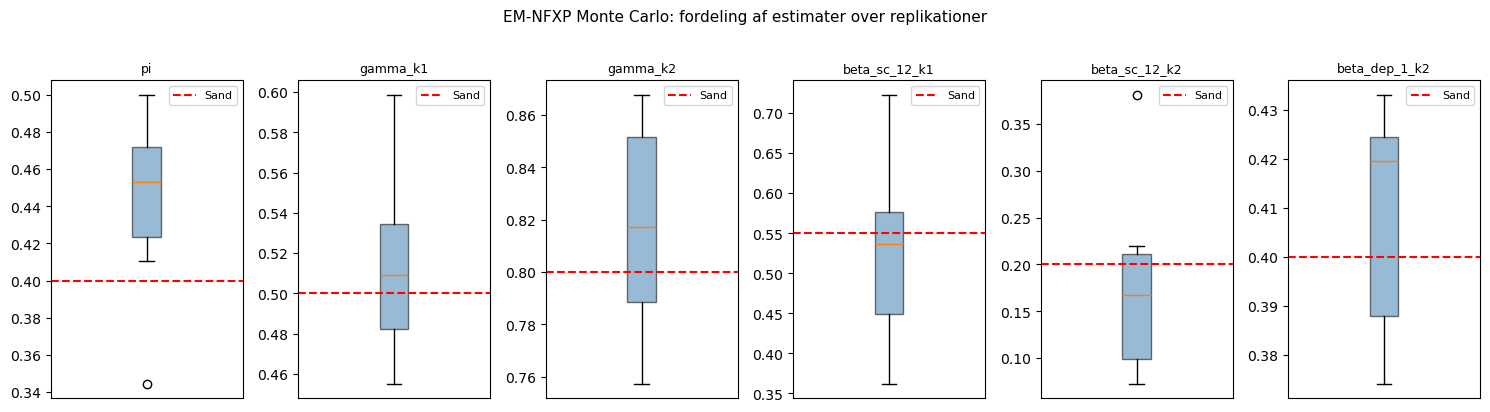

In [15]:
key_params = ['pi', 'gamma_k1', 'gamma_k2', 'beta_sc_12_k1', 'beta_sc_12_k2', 'beta_dep_1_k2']
true_vals  = dict(zip(PARAM_NAMES_EM, THETA_EM_TRUE))

fig, axes = plt.subplots(1, len(key_params), figsize=(15, 4))

for ax, pname in zip(axes, key_params):
    sub = results_df[results_df['parameter'] == pname]['estimate']
    ax.boxplot(sub, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.55))
    ax.axhline(true_vals[pname], color='red', ls='--', lw=1.5, label='Sand')
    ax.set_title(pname, fontsize=9)
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.suptitle('EM-NFXP Monte Carlo: fordeling af estimater over replikationer',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('em_mc_boxplots.pdf', bbox_inches='tight')
plt.show()

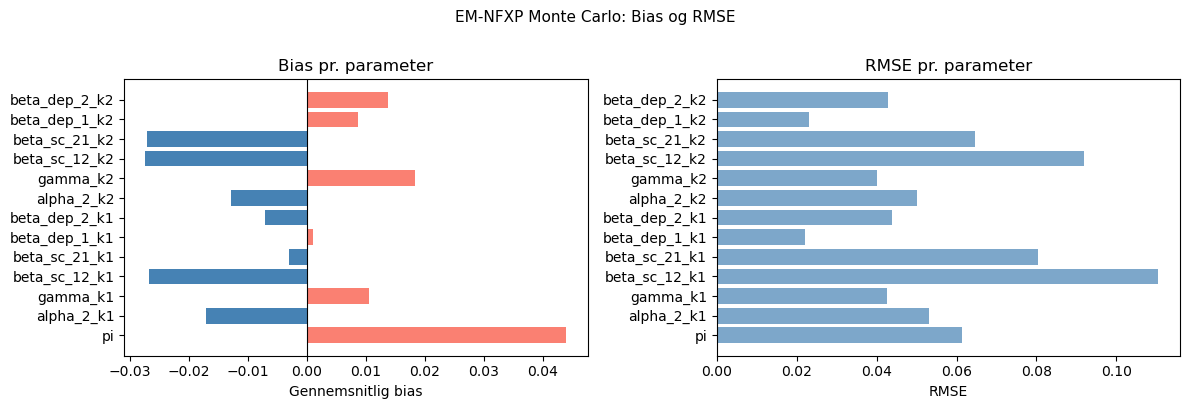

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(summary_df['parameter'], summary_df['bias'],
             color=['salmon' if b > 0 else 'steelblue' for b in summary_df['bias']])
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('Gennemsnitlig bias')
axes[0].set_title('Bias pr. parameter')

axes[1].barh(summary_df['parameter'], summary_df['rmse'], color='steelblue', alpha=0.7)
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE pr. parameter')

plt.suptitle('EM-NFXP Monte Carlo: Bias og RMSE', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('em_mc_bias_rmse.pdf', bbox_inches='tight')
plt.show()